# Module 1: The Problem with Naive RAG

In this module, we will explore why simply "chunking and embedding" technical documents fails. We will build a naive RAG pipeline and observe where it breaks.

In [3]:
import os
import sys
from pathlib import Path

# Add the src directory to the path so we can import shared utilities
sys.path.append(str(Path("../../src").resolve()))

from utils import load_env
import requests

# Load environment variables
env = load_env()
print("Environment loaded.")

Environment loaded.


In [4]:
# Define constants
DATA_DIR = Path("../../data/sample-pdfs")
PDF_PATH = DATA_DIR / "Basic Electrical Engineering R-20.pdf"

# Verify file exists
if not PDF_PATH.exists():
    print(f"⚠️ Warning: File not found at {PDF_PATH}. Please ensure it is in the data folder.")
else:
    print(f"File found: {PDF_PATH}")

File found: ../../data/sample-pdfs/Basic Electrical Engineering R-20.pdf


## Step 1: Naive Ingestion

We will use **Azure AI Document Intelligence** to extract text from the PDF.
However, for this "naive" example, we will treat the document as a **single long string of text**, ignoring the rich structure (tables, headers) that the service provides. This simulates what happens when using simple text extractors like `pypdf`.

In [5]:
from azure.ai.documentintelligence import DocumentIntelligenceClient
from azure.identity import DefaultAzureCredential
from azure.core.credentials import AzureKeyCredential

# Robustness check: Ensure env is loaded even if previous cells were skipped
try:
    env
except NameError:
    import sys
    from pathlib import Path
    # Add src to path if validation fails
    sys.path.append(str(Path("../../src").resolve()))
    from utils import load_env
    env = load_env()
    print("Environment loaded dynamically.")

# Initialize the client
endpoint = env["AZURE_DOCUMENT_INTELLIGENCE_ENDPOINT"]

# Try to use Entra ID (RBAC) first, as Keys might be disabled
try:
    print("Attempting to use DefaultAzureCredential (Entra ID)...")
    credential = DefaultAzureCredential()
    client = DocumentIntelligenceClient(endpoint=endpoint, credential=credential)
except Exception as e:
    print(f"Entra ID init failed, falling back to Key: {e}")
    key = env["AZURE_DOCUMENT_INTELLIGENCE_KEY"]
    client = DocumentIntelligenceClient(endpoint=endpoint, credential=AzureKeyCredential(key))

# Analyze the document
print(f"Analyzing {PDF_PATH}...")
with open(PDF_PATH, "rb") as f:
    # Pass the file stream as the positional argument (body)
    poller = client.begin_analyze_document(
        "prebuilt-layout", 
        f,
        content_type="application/pdf"
    )
    result = poller.result()

print(f"Analysis complete. Extracted {len(result.pages)} pages.")

# NAIVE APPROACH: Just get all the content as one big string
full_text = result.content
print(f"Total characters: {len(full_text)}")
print("First 500 characters:\n")
print(full_text[:500])

Attempting to use DefaultAzureCredential (Entra ID)...
Analyzing ../../data/sample-pdfs/Basic Electrical Engineering R-20.pdf...
Analysis complete. Extracted 110 pages.
Total characters: 162344
First 500 characters:

DEPARTMENT OF HUMANITIES AND SCIENCES
BASIC ELECTRICAL ENGINEERING
BASIC ELECTRICAL ENGINEERING
DIGITAL NOTES
LIVE TO LEARN & LEARN TO SHARE
MALLA REDDY COLLEGE OF ENGINEERING & TECHNOLOGY (Autonomous Institution - UGC, Govt. of India) Recognized under 2(f) and 12 (B) of UGC ACT 1956
(Affiliated to JNTUH, Hyderabad, Approved by AICTE-Accredited by NBA & NACC-'A' Grade - ISO 9001:2015 Certified) Maisammaguda, Dhulapally (Post Via. Hakimpet), Secunderabad -500100, Telangana State, India.
MRCET
EAM


In [6]:
import azure.ai.documentintelligence
import inspect
print(f"Installed version: {azure.ai.documentintelligence.__version__}")
from azure.ai.documentintelligence import DocumentIntelligenceClient
print(f"Signature: {inspect.signature(DocumentIntelligenceClient.begin_analyze_document)}")

Installed version: 1.0.2
Signature: (self, model_id: str, body: Union[azure.ai.documentintelligence.models._models.AnalyzeDocumentRequest, collections.abc.MutableMapping[str, Any], IO[bytes]], *, pages: Optional[str] = None, locale: Optional[str] = None, string_index_type: Union[str, azure.ai.documentintelligence.models._enums.StringIndexType, NoneType] = None, features: Optional[List[Union[str, azure.ai.documentintelligence.models._enums.DocumentAnalysisFeature]]] = None, query_fields: Optional[List[str]] = None, output_content_format: Union[str, azure.ai.documentintelligence.models._enums.DocumentContentFormat, NoneType] = None, output: Optional[List[Union[str, azure.ai.documentintelligence.models._enums.AnalyzeOutputOption]]] = None, **kwargs: Any) -> azure.ai.documentintelligence._operations._patch.AnalyzeDocumentLROPoller[azure.ai.documentintelligence.models._models.AnalyzeResult]


## Step 2: Naive Chunking

Now we will split this text into "chunks" of 500 characters with some overlap. This is a common starting point for RAG, but it is blind to document structure.

In [7]:
def chunk_text(text, size=500, overlap=50):
    chunks = []
    start = 0
    while start < len(text):
        end = start + size
        chunks.append(text[start:end])
        start += (size - overlap)
    return chunks

chunks = chunk_text(full_text)
print(f"Created {len(chunks)} chunks.")

print("\n--- 🔍 EVIDENCE OF FAILURE 1: LOSS OF CONTEXT ---")
print("Here is a random chunk. notice how it likely starts or ends in the middle of a sentence.")
print("This makes it hard for the LLM to understand what this text is actually about.\n")

import random
# Pick a chunk from the middle of the document where tech details are
if len(chunks) > 50:
    sample_chunk = chunks[50] 
    print(f"--- Chunk #50 ---\n{sample_chunk}\n-----------------")
else:
    print(random.choice(chunks))

Created 361 chunks.

--- 🔍 EVIDENCE OF FAILURE 1: LOSS OF CONTEXT ---
Here is a random chunk. notice how it likely starts or ends in the middle of a sentence.
This makes it hard for the LLM to understand what this text is actually about.

--- Chunk #50 ---
RS
I
0
There is a deviation in the V-I characteristics of an independent practical voltage source from the V-I characteristics of an independent ideal voltage source. This is due to the voltage drop across the internal resistance (Rs) of an independent practical voltage source.
Independent Current Sources
An independent current source produces a constant current. This current is independent of the voltage across its two terminals. Independent ideal current source and its V-I characteristics are 
-----------------


--- 1. THE VISUAL REALITY (What the human sees) ---
Notice the equation 'I = dQ/dt' and the variable definitions below it.
Notice the footer at the bottom.


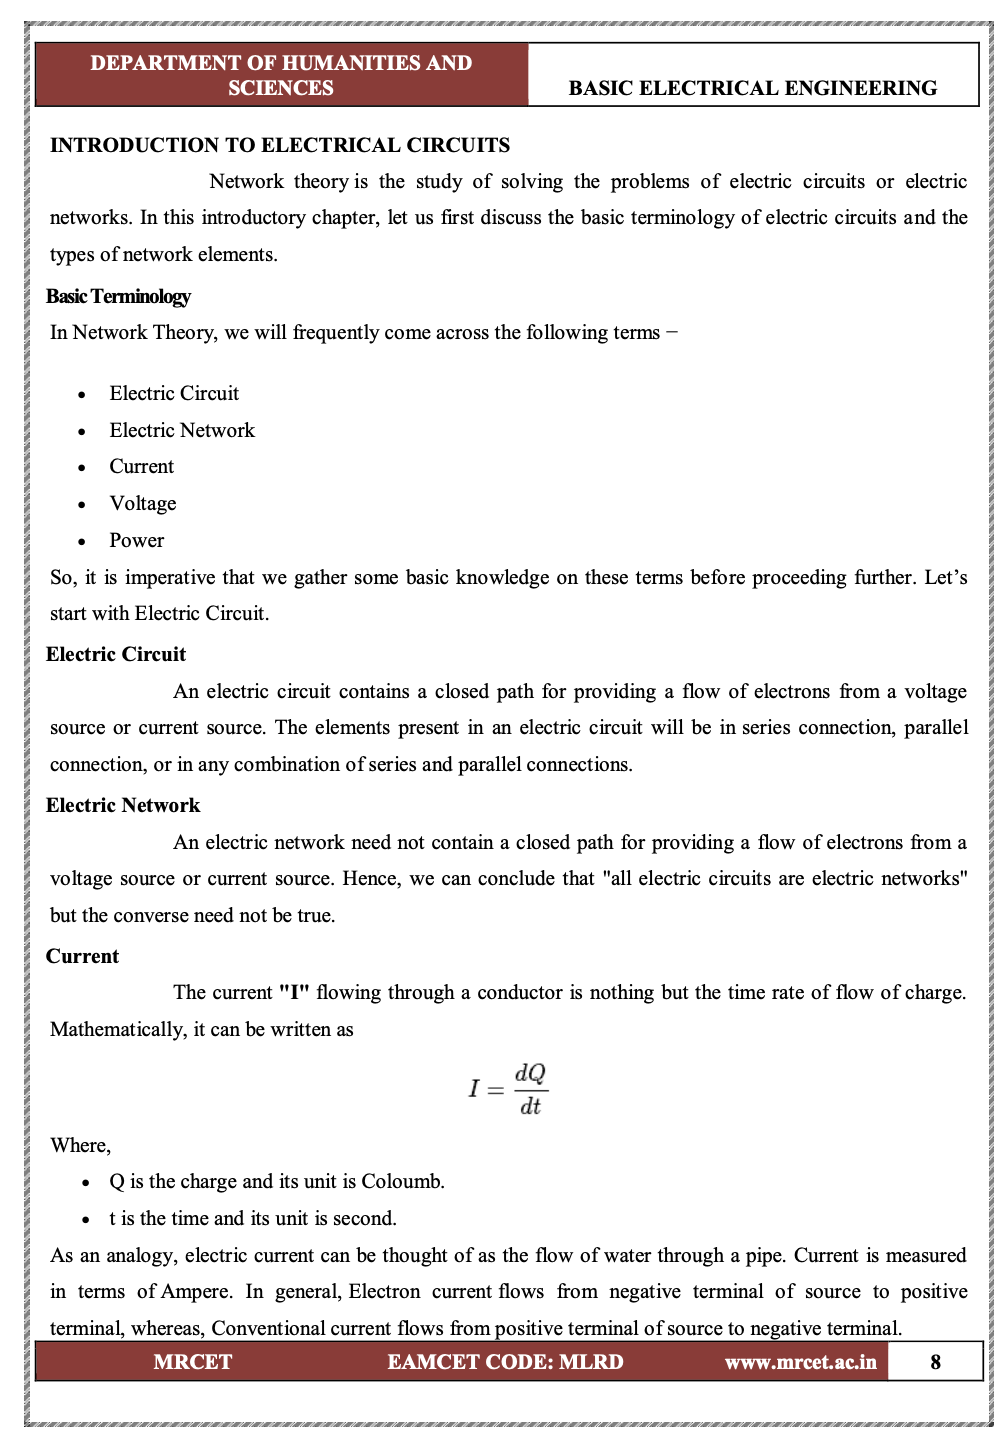


--- 2. THE NAIVE CHUNKING REALITY (What the LLM sees) ---
--- Chunk 1 ---
'DEPARTMENT OF HUMANITIES AND SCIENCES\nBASIC ELECTRICAL ENGINEERING\nINTRODUCTION TO ELECTRICAL CIRCUITS\nNetwork theory is the study of solving the problems of electric circuits or electric networks. In this introductory chapter, let us first discuss the basic terminology of electric circuits and the types of network elements.\nBasic Terminology\nIn Network Theory, we will frequently come across the following terms -\n· Electric Circuit\n· Electric Network\n· Current\n· Voltage\n· Power\nSo, it is imperat'

--- Chunk 2 ---
"work\n· Current\n· Voltage\n· Power\nSo, it is imperative that we gather some basic knowledge on these terms before proceeding further. Let's start with Electric Circuit.\nElectric Circuit\nAn electric circuit contains a closed path for providing a flow of electrons from a voltage source or current source. The elements present in an electric circuit will be in series connection, parallel co

In [8]:
# --- DEEP DIVE: PAGE 8 ANALYSIS ---
from IPython.display import Image, display

print("--- 1. THE VISUAL REALITY (What the human sees) ---")
print("Notice the equation 'I = dQ/dt' and the variable definitions below it.")
print("Notice the footer at the bottom.")
# Display the visual reference (ensure page8.png is in the same folder)
display(Image(filename="page8.png", width=600))

print("\n--- 2. THE NAIVE CHUNKING REALITY (What the LLM sees) ---")

try:
    # Find Page 8
    page_8 = next(p for p in result.pages if p.page_number == 8)
    
    # Extract text
    page_8_text = ""
    for span in page_8.spans:
        page_8_text += result.content[span.offset : span.offset + span.length]

    # Chunk it
    p8_chunks = chunk_text(page_8_text)

    for i, c in enumerate(p8_chunks):
        print(f"--- Chunk {i+1} ---")
        print(f"{c!r}") 
        
        # Auto-detect failures for demonstration
        if "dQ" in c and "unit is Coloumb" in c and "unit is second" not in c:
            print("   🚨 CRITICAL FAILURE: The equation 'I=dQ/dt' is here, but the definition of 't' is MISSING.")
            print("       It got pushed to the next chunk!")
        
        if "time and its unit is second" in c and "dQ" not in c:
             print("   🚨 ORPHAN TEXT: This chunk says 't is time', but the equation it refers to is in the PREVIOUS chunk.")
        
        if "MRCET" in c or "EAMCET" in c:
             print("   🚨 NOISE POLLUTION: Footer usage rights/codes merged with physics content.")
        
        print("")

except StopIteration:
    print("Page 8 not found in the document analysis.")

## Step 3: Minimal Vector Search

We will use OpenAI embeddings to convert these chunks into vectors and store them in a simple in-memory list. We'll then use cosine similarity to find the "best" chunk for a query.

In [11]:
from openai import AzureOpenAI
from azure.identity import DefaultAzureCredential, get_bearer_token_provider
import numpy as np

# Initialize OpenAI Client
# We use Entra ID (RBAC) because Key-based authentication is disabled on this resource
token_provider = get_bearer_token_provider(
    DefaultAzureCredential(), "https://cognitiveservices.azure.com/.default"
)

oai_client = AzureOpenAI(
    azure_endpoint=env["AZURE_OPENAI_ENDPOINT"],
    azure_ad_token_provider=token_provider,
    api_version="2023-05-15"
)

embedding_model = env.get("AZURE_OPENAI_EMBEDDING_DEPLOYMENT", "text-embedding-3-large") # Use env var or default

def get_embedding(text):
    response = oai_client.embeddings.create(input=[text], model=embedding_model)
    return response.data[0].embedding

# Embed a subset of chunks (to save time/cost in this lab, or all if small)
# For the full user guide (~100 pages), let's limit to first 200 chunks for the demo
demo_chunks = chunks[:200] 
print(f"Embedding {len(demo_chunks)} chunks...")

embeddings = [get_embedding(chunk) for chunk in demo_chunks]
print("Embeddings created.")

def naive_search(query, k=3):
    query_vec = get_embedding(query)
    similarities = [np.dot(query_vec, doc_vec) for doc_vec in embeddings]
    # Get top k indices
    top_k_indices = np.argsort(similarities)[-k:][::-1]
    return [(demo_chunks[i], similarities[i]) for i in top_k_indices]

print("Search ready.")

Embedding 200 chunks...
Embeddings created.
Search ready.


## Step 4: Failure Mode Analysis

Now let's ask questions that require understanding **tables** or **figures**.

### Test 1: Table Data
Attempt to retrieve specific specs that likely live in a table (e.g., "What is the weight of the device?"). Notice how the table row might be split across chunks, or the headers are missing from the chunk containing the value.

In [ ]:
# --- 🔍 EVIDENCE OF FAILURE 2: DATA INTEGRITY (TABLE DESTRUCTION) ---
from IPython.display import Image, display

# We will focus on the INDEX TABLE on Page 5 to show how structure is lost.
found_table = None
target_page = 5

try:
    # Find the specific table on Page 5 (The Index)
    found_table = next(t for t in result.tables if t.bounding_regions[0].page_number == target_page)
    
    print(f"--- 1. THE VISUAL REALITY (Index Table on Page {target_page}) ---")
    print("This is the structured data explicitly extracted by Azure AI Document Intelligence.")
    print("Notice the row/column relationships imply 'Topic' -> 'Page Number'.\n")
    
    # Display the visual reference
    try:
        display(Image(filename="page5.png", width=600))
    except:
        print("Image 'page5.png' not found. Please ensure it is in the module folder.")

    # Reconstruct the table for display
    print("\n[Ground Truth Table Reconstructed from Document Intelligence Data]:")
    # Create a grid
    grid = [["" for _ in range(found_table.column_count)] for _ in range(found_table.row_count)]
    for cell in found_table.cells:
        # Access cell content directly
        grid[cell.row_index][cell.column_index] = cell.content.replace("\n", " ")
    
    # Print as a nice ASCII table
    col_widths = [max(len(cell) for cell in col) + 2 for col in zip(*grid)]
    
    def print_row(row):
        print("|" + "|".join(cell.ljust(width) for cell, width in zip(row, col_widths)) + "|")

    print("-" * (sum(col_widths) + len(col_widths) + 1))
    for row in grid:
        print_row(row)
        print("-" * (sum(col_widths) + len(col_widths) + 1))
        
    print(f"\nThis table contains {len(found_table.cells)} cells of informative data.")

    print("\n--- 2. THE NAIVE CHUNKING REALITY (What the LLM sees) ---")
    print("Now we find the chunk that contains this text. Notice how the columns vanish.")
    
    # Find the chunks that contain this table's content
    # We search for "Concept of Circuit" + "7-8" which appear in the table
    # but likely appear 'mashed' in the chunk
    
    unique_phrase = "Concept of Circuit"
    
    matching_chunks = [c for c in chunks if unique_phrase in c]
    
    if matching_chunks:
        print(f"Found {len(matching_chunks)} chunk(s) containing the Index:\n")
        for i, c in enumerate(matching_chunks):
            print(f">>> CHUNK {i+1} PREVIEW:")
            print(c) 
            print("...\n")
            print("👉 CRITICAL FAILURE:")
            print("   1. Where is the 'Page No' column header?")
            print("   2. Is '7-8' clearly associated with 'Concept of Circuit' as a page number?")
            print("   3. Or does it look like 'Concept of Circuit and Network 7-8' is just one long sentence?")
            print("   4. Without structure, an LLM likely ignores the page numbers or thinks they are part of the title.")
    else:
        print("Could not locate the specific table text in the chunks.")

except StopIteration:
    print(f"Table on Page {target_page} not found.")

Query: What is the equation for Ohm's law?


NameError: name 'naive_search' is not defined

### Test 2: Figures and Diagrams (Page 12)
Technical documents rely heavily on diagrams. On Page 12, there is a circuit diagram.
Visual information is completely lost in naive text extraction.

**Discussion Question:** If you feed the text below to GPT-4, will it be able to draw the circuit? Will it know that R1 and R2 are in parallel?

--- 1. THE VISUAL REALITY (Circuit Diagram on Page 12) ---
This defines the circuit topology (R1, R2, V, I directions).
Crucially, the KCL equation 'Is = I1 + I2' only makes sense with this diagram.



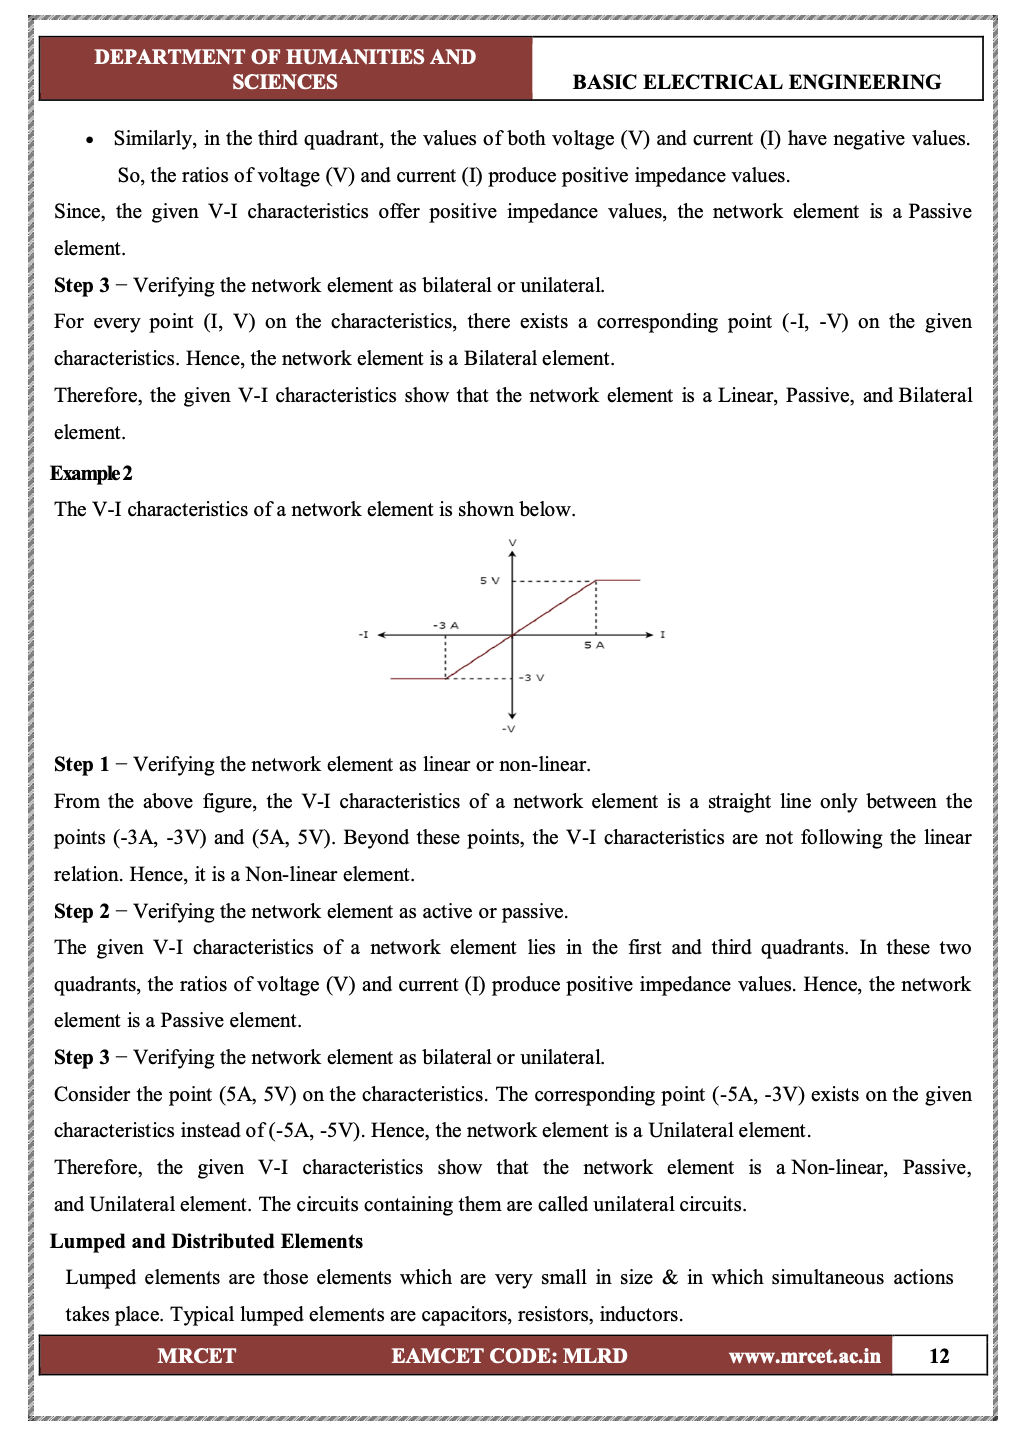


--- 2. THE NAIVE CHUNKING REALITY (What the LLM sees) ---
We extract text from Page 12. Does it describe the connections?
Does it say 'R1 is in parallel with R2'? Or just list labels?

>>> EXTRACTED TEXT FROM PAGE 12 (Partial):
DEPARTMENT OF HUMANITIES AND SCIENCES
BASIC ELECTRICAL ENGINEERING
· Similarly, in the third quadrant, the values of both voltage (V) and current (I) have negative values. So, the ratios of voltage (V) and current (I) produce positive impedance values.
Since, the given V-I characteristics offer positive impedance values, the network element is a Passive element.
Step 3 - Verifying the network element as bilateral or unilateral.
For every point (I, V) on the characteristics, there exists a corresponding point (-I, -V) on the given characteristics. Hence, the network element is a Bilateral element.
Therefore, the given V-I characteristics show that the network element is a Linear, Passive, and Bilateral element.
Example 2
The V-I characteristics of a network elem

In [12]:
# --- 🔍 EVIDENCE OF FAILURE 3: FIGURE LOSS ---
from IPython.display import Image, display

target_page = 12

print(f"--- 1. THE VISUAL REALITY (Circuit Diagram on Page {target_page}) ---")
print("This defines the circuit topology (R1, R2, V, I directions).")
print("Crucially, the KCL equation 'Is = I1 + I2' only makes sense with this diagram.\n")

try:
    display(Image(filename="page12.png", width=600))
except:
    print("page12.png not found")

print("\n--- 2. THE NAIVE CHUNKING REALITY (What the LLM sees) ---")
print("We extract text from Page 12. Does it describe the connections?")
print("Does it say 'R1 is in parallel with R2'? Or just list labels?\n")

try:
    # Get page 12 text
    # Note: result.pages is a list, we find the one with page_number == 12
    p12 = next(p for p in result.pages if p.page_number == target_page)
    
    page_12_text = ""
    for span in p12.spans:
        page_12_text += result.content[span.offset : span.offset + span.length]
        
    print(">>> EXTRACTED TEXT FROM PAGE 12 (Partial):")
    # Show the text around where the diagram likely is (usually has labels like R1, R2)
    # or just print the whole page text if it's not too long
    print(page_12_text) 
    print("\n--------------------------")
    print("👉 CRITICAL FAILURE:")
    print("   1. The diagram is GONE.")
    print("   2. You might see labels like 'R1', 'R2', 'Vs' floating in the text, or mashed together.")
    print("   3. An LLM cannot reconstruct the circuit topology (Series vs Parallel) from this flat text.")

except StopIteration:
    print(f"Page {target_page} not found.")

## Conclusion

You have just seen **Naive RAG** in action. It is fast to build, but it destroys the meaning of complex documents.
In the next module, we will learn how to use **Document Intelligence** properly to preserve this structure.